# Explaining Riemannian

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from IPython.display import display, Markdown
#from denoising_diffusion_pytorch import Unet1D, GaussianDiffusion1D, Trainer1D, Dataset1D
from scipy.stats import wasserstein_distance

seed = 42
torch.manual_seed(seed)

Say we draw 5000 samples from the following distribution

$$
z_0 \sim \mathcal{N}\!\left(
\begin{pmatrix}
0.0 \\
0.0
\end{pmatrix},
\begin{pmatrix}
1.0 & 0.9 \\
0.9 & 1.0
\end{pmatrix}
\right)
$$


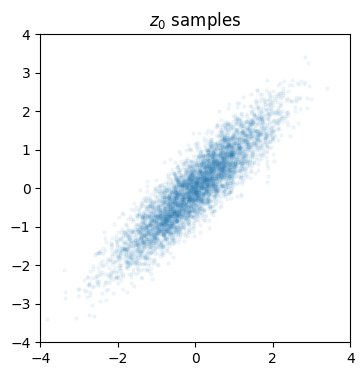

In [2]:
N = 5000

mean = torch.tensor([0.0, 0.0])

Sigma = torch.tensor([[1.0, 0.9],
                      [0.9, 1.0]])

md = f"""Say we draw {N} samples from the following distribution

$$
z_0 \\sim \\mathcal{{N}}\\!\\left(
\\begin{{pmatrix}}
{mean[0]:.1f} \\\\
{mean[1]:.1f}
\\end{{pmatrix}},
\\begin{{pmatrix}}
{Sigma[0,0]:.1f} & {Sigma[0,1]:.1f} \\\\
{Sigma[1,0]:.1f} & {Sigma[1,1]:.1f}
\\end{{pmatrix}}
\\right)
$$
"""

display(Markdown(md))

dist = torch.distributions.MultivariateNormal(
    loc=torch.zeros(2),
    covariance_matrix=Sigma
)

z_0 = dist.sample((N,))

plt.figure(figsize=(4, 4))
plt.scatter(z_0[:, 0], z_0[:, 1], s=5, alpha=0.05)
plt.title(r"$z_0$ samples")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.show()

Then we add some noise
$$z = \sqrt{1-\beta} z_0 + \sqrt{\beta} \epsilon, \quad \epsilon \sim N(0,1), \quad \beta = 0.50$$


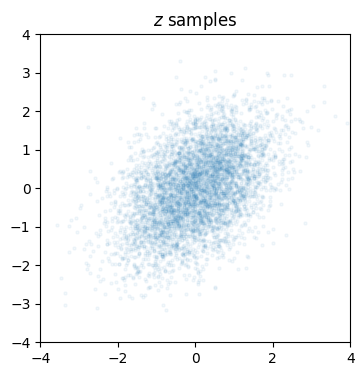

In [3]:
beta = 0.5

md = f"""Then we add some noise
$$z = \\sqrt{{1-\\beta}} z_0 + \\sqrt{{\\beta}} \\epsilon, \\quad \\epsilon \\sim N(0,1), \\quad \\beta = {beta:.2f}$$
"""

display(Markdown(md))

epsilon = torch.normal(0,1,(N,2))
z = np.sqrt(1-beta)*z_0 + np.sqrt(beta)*epsilon

plt.figure(figsize=(4, 4))
plt.scatter(z[:, 0], z[:, 1], s=5, alpha=0.05)
plt.title(r"$z$ samples")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.show()

Let us empirically evaluate
$$\epsilon \mid z $$
Say $z^*$ is just the neighborhood around (-1,1) of radius 0.5


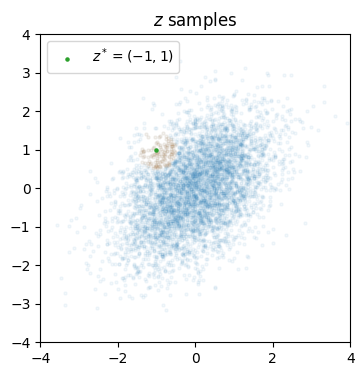

In [4]:
z_star_x = -1
z_star_y = 1
r = 0.5

md = f"""Let us empirically evaluate
$$\epsilon \mid z $$
Say $z^*$ is just the neighborhood around ({z_star_x},{z_star_y}) of radius {r}
"""

display(Markdown(md))

z_star = torch.tensor([z_star_x,z_star_y]).unsqueeze(0)


mask = np.linalg.norm(z - z_star, axis=1) < r
z_star_radius = z[mask]

plt.figure(figsize=(4, 4))
plt.scatter(z[:, 0], z[:, 1], s=5, alpha=0.05)
plt.scatter(z_star_radius[:, 0], z_star_radius[:, 1], s=5, alpha=0.05)
plt.scatter(z_star[:, 0], z_star[:, 1], s=5, label = fr"$z^* = ({z_star_x}, {z_star_y})$")
plt.title(r"$z$ samples")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.show()

In [5]:
epsilon_radius = epsilon[mask]

epsilon_radius_x = epsilon_radius[:,0] 
epsilon_radius_y = epsilon_radius[:,1] 

mean_x = epsilon_radius_x.mean().item()
mean_y = epsilon_radius_y.mean().item()

cov_xy = ((epsilon_radius_x - mean_x)*(epsilon_radius_y - mean_y)).mean().item()

md = f"""We find the empirical mean and covariance of $\\epsilon \\mid x^*$
$$
\\epsilon_{{data}} \\mid x^*_{{r}} \\sim \\mathcal{{N}}\\!\\left(
\\begin{{pmatrix}}
{mean_x:.2f} \\\\
{mean_y:.2f}
\\end{{pmatrix}},
\\begin{{pmatrix}}
{epsilon_radius_x.var().item():.2f} & {cov_xy:.2f} \\\\
{cov_xy:.2f} & {epsilon_radius_y.var().item():.2f}
\\end{{pmatrix}}
\\right)
$$
"""

display(Markdown(md))


We find the empirical mean and covariance of $\epsilon \mid x^*$
$$
\epsilon_{data} \mid x^*_{r} \sim \mathcal{N}\!\left(
\begin{pmatrix}
-1.24 \\
1.02
\end{pmatrix},
\begin{pmatrix}
0.37 & 0.23 \\
0.23 & 0.40
\end{pmatrix}
\right)
$$


We now double-check this theoretically. Conditioning on \(z\) is equivalent to imposing the constraint
$$
z_0 \;=\; \frac{1}{\sqrt{1-\beta}}\bigl(z - \sqrt{\beta}\,\epsilon\bigr).
$$

By Bayes’ rule,
$$
p(\epsilon \mid z)
\;\propto\;
p(\epsilon)\,
p\!\left(
z_0 = \frac{1}{\sqrt{1-\beta}}\bigl(z - \sqrt{\beta}\,\epsilon\bigr)
\right).
$$

Using Gaussian densities, we obtain
$$
\log p(\epsilon \mid z)
=
-\tfrac12\,\epsilon^\top \epsilon
-
\tfrac{1}{2(1-\beta)}
\bigl(z-\sqrt{\beta}\,\epsilon\bigr)^\top
\Sigma^{-1}
\bigl(z-\sqrt{\beta}\,\epsilon\bigr)
+\text{const}.
$$

Expanding the quadratic form gives
$$
\bigl(z-\sqrt{\beta}\,\epsilon\bigr)^\top
\Sigma^{-1}
\bigl(z-\sqrt{\beta}\,\epsilon\bigr)
=
z^\top\Sigma^{-1}z
-
2\sqrt{\beta}\,\epsilon^\top\Sigma^{-1}z
+
\beta\,\epsilon^\top\Sigma^{-1}\epsilon.
$$

Collecting all terms that depend on \(\epsilon\), we obtain
$$
\log p(\epsilon\mid z)
=
-\tfrac12\,
\epsilon^\top
\Bigl(
I+\tfrac{\beta}{1-\beta}\Sigma^{-1}
\Bigr)
\epsilon
+
\epsilon^\top
\Bigl(
\tfrac{\sqrt{\beta}}{1-\beta}\Sigma^{-1}z
\Bigr)
+
\text{const}.
$$

Therefore, the conditional distribution is Gaussian,
$$
\epsilon \mid z
\;\sim\;
\mathcal N\!\left(
\mu_{\epsilon\mid z},
\;\Lambda_{\epsilon\mid z}
\right),
$$
with
$$
\Lambda_{\epsilon\mid z}
=
\Bigl(
I+\tfrac{\beta}{1-\beta}\Sigma^{-1}
\Bigr)^{-1},
$$
and
$$
\mu_{\epsilon\mid z}
=
\Lambda_{\epsilon\mid z}
\Bigl(
\tfrac{\sqrt{\beta}}{1-\beta}\Sigma^{-1}z
\Bigr).
$$


In [6]:
Sigma_inv = torch.linalg.inv(Sigma)
eye = torch.eye(2, dtype=Sigma.dtype, device=Sigma.device)

z_star_vec = z_star.to(dtype=Sigma.dtype).reshape(2, 1)

Lambda = torch.linalg.inv(eye + (beta / (1- beta))* Sigma_inv)
mu_theor = Lambda @ ((np.sqrt(beta) / (1-beta)) * Sigma_inv @ z_star_vec)

md = f"""
So theoretically, at $x^* = ({z_star_x}, {z_star_y})$, we get
$$
\\epsilon_{{theoretical}} \\mid x^* \\sim \\mathcal{{N}}\\!\\left(
\\begin{{pmatrix}}
{mu_theor[0, 0].item():.2f} \\\\
{mu_theor[1, 0].item():.2f}
\\end{{pmatrix}},
\\begin{{pmatrix}}
{Lambda[0, 0].item():.2f} & {Lambda[0, 1].item():.2f} \\\\
{Lambda[1, 0].item():.2f} & {Lambda[1, 1].item():.2f}
\\end{{pmatrix}}
\\right).
$$
"""

display(Markdown(md))



So theoretically, at $x^* = (-1, 1)$, we get
$$
\epsilon_{theoretical} \mid x^* \sim \mathcal{N}\!\left(
\begin{pmatrix}
-1.29 \\
1.29
\end{pmatrix},
\begin{pmatrix}
0.37 & 0.28 \\
0.28 & 0.37
\end{pmatrix}
\right).
$$


## Using a NN 

In [7]:
n_epochs = 1000
batch_size = 100

md = f"""
If we try to estimate this conditional using a neural network in the DDPM
noise-prediction parameterization, we minimize
$$
\\mathcal{{L}}(\\theta)
=
\\mathbb{{E}}_{{x_0 \\sim p_{{\\text{{data}}}},\\; \\epsilon \\sim \\mathcal{{N}}(0,I)}}
\\left[
\\left\\|
\\epsilon
-
\\epsilon_\\theta(x)
\\right\\|_2^2
\\right],
\\qquad
x = x_0 + \\sigma \\epsilon.
$$

We perform basic training using this DDPM objective.
We train for {n_epochs} epochs with batch size {batch_size},
which is sufficient given the small number of samples.
"""
display(Markdown(md))



If we try to estimate this conditional using a neural network in the DDPM
noise-prediction parameterization, we minimize
$$
\mathcal{L}(\theta)
=
\mathbb{E}_{x_0 \sim p_{\text{data}},\; \epsilon \sim \mathcal{N}(0,I)}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x)
\right\|_2^2
\right],
\qquad
x = x_0 + \sigma \epsilon.
$$

We perform basic training using this DDPM objective.
We train for 1000 epochs with batch size 100,
which is sufficient given the small number of samples.


In [8]:
class MLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x):
        return self.net(x)

model_single_t = MLP()
optimizer = optim.AdamW(model_single_t.parameters(), lr=1e-3)

for i in range(n_epochs):
    rand_samples = torch.randint(0,N, (batch_size,))
    z_batch = z[rand_samples]
    eps_batch = epsilon[rand_samples]
    pred = model_single_t(z_batch)
    loss = ((pred - eps_batch) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Now, we have our DDPM reverse distribution estimate of $\epsilon \mid x^*$. Note as per the DDPM paper, we use our model output to estimate the mean of this distribution and $I$ as our covariance 

In [9]:
pred_epsilon = model_single_t(z_star.float())

md = f"""We get the following estimate of our distribution after learning:
$$
\\epsilon_{{model}} \\mid x^*  \\sim \\mathcal{{N}}\\!\\left(
\\begin{{pmatrix}}
{pred_epsilon[0,0].item():.2f} \\\\
{pred_epsilon[0,1].item():.2f}
\\end{{pmatrix}},
\\begin{{pmatrix}}
{1:.2f} & {0:.2f} \\\\
{0:.2f} & {1:.2f}
\\end{{pmatrix}}
\\right)
$$
"""

display(Markdown(md))

We get the following estimate of our distribution after learning:
$$
\epsilon_{model} \mid x^*  \sim \mathcal{N}\!\left(
\begin{pmatrix}
-1.21 \\
1.23
\end{pmatrix},
\begin{pmatrix}
1.00 & 0.00 \\
0.00 & 1.00
\end{pmatrix}
\right)
$$


## Reconstructing the covariance matrix from $\epsilon_{\theta}$

Remember how we defined theoretically,
$$
\epsilon \mid z
\;\sim\;
\mathcal N\!\left(
\mu_{\epsilon\mid z},
\;\Lambda_{\epsilon\mid z}
\right),
$$
with
$$
\Lambda_{\epsilon\mid z}
=
\Bigl(
I+\tfrac{\beta}{1-\beta}\Sigma^{-1}
\Bigr)^{-1},
$$
and
$$
\mu_{\epsilon\mid z}
=
\Lambda_{\epsilon\mid z}
\Bigl(
\tfrac{\sqrt{\beta}}{1-\beta}\Sigma^{-1}z
\Bigr).
$$
We can approximate $\Sigma$ using all samples of $z$
$$\Sigma_{rie} = \frac{1}{1-\beta} (E[z^T z] - \beta \cdot I)$$

In [10]:
outer = z.T @ z
outer = outer / z.shape[0]

outer = (1/ (1-beta)) * (outer - beta * eye)


md = f"""We get the following estimate of our data's covariance matrix:
$$
\Sigma_{{rie}} =
\\begin{{pmatrix}}
{outer[0,0].item():.2f} & {outer[0,1].item():.2f} \\\\
{outer[1,0].item():.2f} & {outer[1,1].item():.2f}
\\end{{pmatrix}}
$$
"""

display(Markdown(md))

We get the following estimate of our data's covariance matrix:
$$
\Sigma_{rie} =
\begin{pmatrix}
0.99 & 0.91 \\
0.91 & 1.03
\end{pmatrix}
$$


Then we redefine our epsilon's covariance matrix as per 
$$\Lambda_{\epsilon\mid z}
=
\Bigl(
I+\tfrac{\beta}{1-\beta}\Sigma^{-1}
\Bigr)^{-1},$$

In [11]:
Sigma_inv = torch.linalg.inv(outer)
eye = torch.eye(2, dtype=Sigma.dtype, device=Sigma.device)

z_star_vec = z_star.to(dtype=Sigma.dtype).reshape(2, 1)

Lambda = torch.linalg.inv(eye + (beta /(1-beta))* Sigma_inv)

Lambda_xx = Lambda[0, 0].item()
Lambda_yy = Lambda[1, 1].item()
Lambda_xy = Lambda[0, 1].item()

md = f"""
So we get a new covariance matrix 

$$\\epsilon_{{rie}} \mid z^* \\sim \\mathcal{{N}}\\!\\left(\\mu, 
\\begin{{pmatrix}}
{Lambda_xx:.2f} & {Lambda_xy:.2f} \\\\
{Lambda_xy:.2f} & {Lambda_yy:.2f}
\\end{{pmatrix}}
\\right)
$$
"""

display(Markdown(md))


So we get a new covariance matrix 

$$\epsilon_{rie} \mid z^* \sim \mathcal{N}\!\left(\mu, 
\begin{pmatrix}
0.37 & 0.28 \\
0.28 & 0.38
\end{pmatrix}
\right)
$$



Let us now run each reverse process for a single step and compare the results.
We apply the reverse update
$$
x_0
=\frac{1}{\sqrt{1-\beta}} (
 x
-
\sqrt{\beta}\,\epsilon_{\text{model}}(x)),
$$
where $\epsilon_{\text{model}}(x)$ is the noise predicted by the trained network.


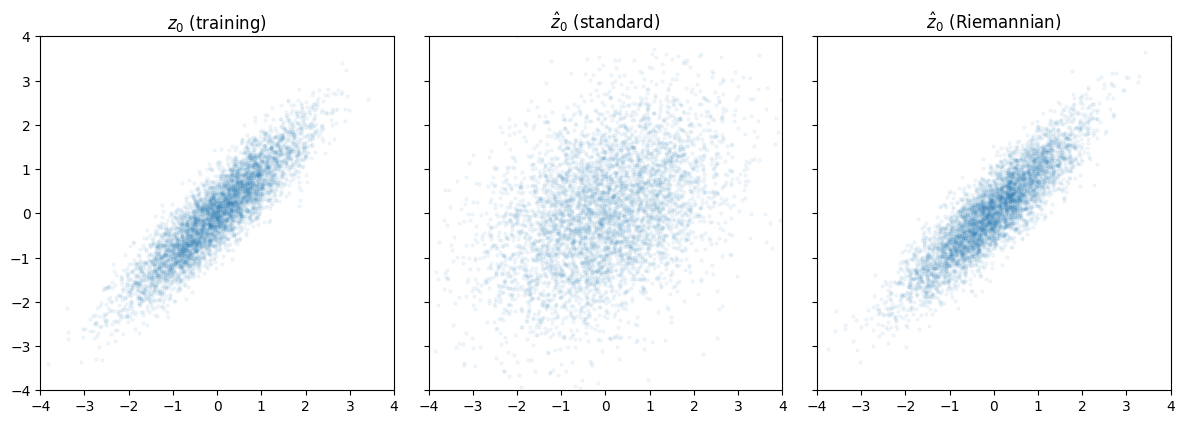

In [12]:
md = r"""
Let us now run each reverse process for a single step and compare the results.
We apply the reverse update
$$
x_0
=\frac{1}{\sqrt{1-\beta}} (
 x
-
\sqrt{\beta}\,\epsilon_{\text{model}}(x)),
$$
where $\epsilon_{\text{model}}(x)$ is the noise predicted by the trained network.
"""
display(Markdown(md))

cov_standard = torch.eye(2)

epsilon_hat = model_single_t(z.float())               # mean of ε | x
noise = torch.randn_like(epsilon_hat)            # N(0, I)

epsilon_sample = epsilon_hat + noise @ cov_standard.T
z_0_estimate = (1/np.sqrt(1-beta)) * (z - np.sqrt(beta) * epsilon_sample)
z_0_estimate_standard = z_0_estimate.detach().cpu().numpy()



cov_riemann = torch.linalg.cholesky(Lambda)  # more stable than sqrtm

epsilon_hat = model_single_t(z.float())               # mean of ε | x
noise = torch.randn_like(epsilon_hat)            # N(0, I)

epsilon_sample = epsilon_hat + noise @ cov_riemann.T
z_0_estimate = (1/np.sqrt(1-beta)) * (z - np.sqrt(beta) * epsilon_sample)
z_0_estimate_riemann = z_0_estimate.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

# (1) Training / true z_0
axes[0].scatter(z_0[:, 0], z_0[:, 1], s=5, alpha=0.05)
axes[0].set_title(r"$z_0$ (training)")

# (2) Standard isotropic reverse
axes[1].scatter(
    z_0_estimate_standard[:, 0],
    z_0_estimate_standard[:, 1],
    s=5,
    alpha=0.05,
)
axes[1].set_title(r"$\hat z_0$ (standard)")

# (3) Riemannian / correlated reverse
axes[2].scatter(
    z_0_estimate_riemann[:, 0],
    z_0_estimate_riemann[:, 1],
    s=5,
    alpha=0.05,
)
axes[2].set_title(r"$\hat z_0$ (Riemannian)")

for ax in axes:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Full DDPM

Bugs atm

In [13]:
# num_epochs_ddpm = 1000
# timesteps = 1000
# bs_ddpm = 100
# mode = "sampling"

# md = f"""Let us now run the full {mode} process with {timesteps} timesteps, {num_epochs_ddpm} epochs, and {bs_ddpm} batch size.
# """

# display(Markdown(md))

In [14]:
# def normalize(z_0, std):
#     return ((z_0 / std )+0.5).unsqueeze(-1)

# normalization_factor = 10
# z_0_normalized = normalize(z_0, normalization_factor)

# outer_norm = z_0_normalized.squeeze(-1).T @ z_0_normalized.squeeze(-1)
# outer_norm = outer_norm / z_0_normalized.shape[0]

# md = f"""First we normalize our training samples between 0 and 1. 
# We minimize by a factor of {normalization_factor} and get 
# sample min {z_0_normalized.min().item():.2f} 
# and max {z_0_normalized.max().item():.2f}. Covariance looks like [{outer_norm[0,0]:.2f}, {outer_norm[0,1]:.2f}], [{outer_norm[1,0]:.2f}, {outer_norm[1,1]:.2f}]
# """

# display(Markdown(md))

# assert z_0_normalized.min() >= 0.0 - 1e-6
# assert z_0_normalized.max() <= 1.0 + 1e-6


In [15]:
# model = Unet1D(
#     dim = 64,
#     dim_mults = (1, ),
#     channels = 2
# )

# diffusion = GaussianDiffusion1D(
#     model,
#     seq_length = 1,
#     timesteps = timesteps,
#     objective = 'pred_noise'
# )

# # Using trainer

# dataset = Dataset1D(z_0_normalized)  # this is just an example, but you can formulate your own Dataset and pass it into the `Trainer1D` below

# trainer = Trainer1D(
#     diffusion,
#     dataset = dataset,
#     train_batch_size = bs_ddpm,
#     train_lr = 8e-5,
#     train_num_steps = num_epochs_ddpm,         # total training steps
#     save_and_sample_every = 100000, # gets saved to "results" folder (disable with high save_and_sample_every)
#     gradient_accumulate_every = 2,    # gradient accumulation steps
#     ema_decay = 0.995,                # exponential moving average decay
#     amp = True,                       # turn on mixed precision
# )

# if mode == "training":
#     trainer.train()

#     torch.save(
#         model.state_dict(),
#         f"model_checkpoints/riemann/{num_epochs_ddpm}_aniso.pt"
#     ) 

# if mode == "sampling":
#     state_dict = torch.load(f"model_checkpoints/riemann/{num_epochs_ddpm}_aniso.pt", map_location="cpu")
#     model.load_state_dict(state_dict)


In [16]:
# def unnormalize(z_0, normalization_factor):
#     z_0 = z_0.squeeze(-1).detach().cpu().numpy()
#     return (z_0-0.5) * normalization_factor

# md = f"""We then run sampling and unnormalize then plot our samples
# """

# display(Markdown(md))

# z_0_samples_rie = diffusion.sample(
#     k=1.0,
#     k_cns=1.0,
#     tau=float(1.0),
#     n_chunks=10,
#     batch_size=N
# )

# z_0_unnormalized_rie = unnormalize(z_0_samples_rie, normalization_factor)


# z_0_samples = diffusion.sample(
#     k=1.0,
#     k_cns=1.0,
#     tau=float(0.0),
#     n_chunks=10,
#     batch_size=N
# )

# z_0_unnormalized = unnormalize(z_0_samples, normalization_factor)

# fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

# # (1) Training / true z_0
# axes[0].scatter(z_0[:, 0], z_0[:, 1], s=5, alpha=0.05)
# axes[0].set_title(r"$z_0$ (training)")

# # (2) Standard isotropic reverse
# axes[1].scatter(
#     z_0_unnormalized[:, 0],
#     z_0_unnormalized[:, 1],
#     s=5,
#     alpha=0.05,
# )
# axes[1].set_title(r"$\hat z_0$ (standard)")

# # (3) Riemannian / correlated reverse
# axes[2].scatter(
#     z_0_unnormalized_rie[:, 0],
#     z_0_unnormalized_rie[:, 1],
#     s=5,
#     alpha=0.05,
# )
# axes[2].set_title(r"$\hat z_0$ (Riemannian)")

# for ax in axes:
#     ax.set_xlim(-4, 4)
#     ax.set_ylim(-4, 4)
#     ax.set_aspect("equal")

# plt.tight_layout()
# plt.show()

In [17]:
# wx_std = wasserstein_distance(z_0[:, 0], z_0_unnormalized[:, 0])
# wy_std = wasserstein_distance(z_0[:, 1], z_0_unnormalized[:, 1])

# wx_rie = wasserstein_distance(z_0[:, 0], z_0_unnormalized_rie[:, 0])
# wy_rie = wasserstein_distance(z_0[:, 1], z_0_unnormalized_rie[:, 1])

# wass_std = 0.5 * (wx_std + wy_std)
# wass_rie = 0.5 * (wx_rie + wy_rie)


# # Right: avg 1D Wasserstein
# plt.bar(["Standard", "Riemannian"], [wass_std, wass_rie])
# plt.title(r"Avg. 1D Wasserstein")
# plt.ylabel("distance")

# plt.tight_layout()
# plt.show()
